# Louisville Roadway Risk Analysis, 2018 - 2022
### Risk assessment for pedestrians and cyclists in Louisville, KY
All data sourced from [Louisville Metro Open Data](https://data.louisvilleky.gov/)

---


### General Setup and Data Imports

Import libraries needed to assess Louisville data, including geographic data.

In [1]:
import pandas as pd   # for creating dataframes
import geopandas as gpd   # for reading data sets in GeoJSON files
from geopy.distance import geodesic   # for converting shape lengths calculated in degrees to miles
import matplotlib.pyplot as plt   # for plotting visualizations
import matplotlib.patches as mpatches   # for custom visualization labels
from matplotlib import colormaps   # for access to colormaps used in visualizations
from shapely.geometry import Point, LineString, MultiLineString, shape   # for geopandas geometry management
import sqlite3   # for reading to and writing from SQLite database files

Read in various geodata files and shapefiles. Ensure their CRS are aligned, and clip the data to within Jefferson County only.

In [2]:
# geometric shapefile to draw Jefferson County
county_shape = gpd.read_file('data/Ky_County_Polygons/Ky_County_Polygons_WM.shp')
county_shape.to_crs(epsg='4326', inplace=True)      # the GeoJSON files provided by data.louisville.gov use CRS EPSG:4326
jefferson_co = county_shape[county_shape['NAME']=='JEFFERSON']

# major roads data for Louisville metro area includes southern Indiana; clip to Jefferson County
major_roads = gpd.read_file('data/Louisville_Metro_Area_KY_Major_Roads.geojson')
major_roads.dropna(inplace=True)    # one row had mostly NaN values
# clip major roads to Jefferson County only
jeffco_roads = gpd.clip(major_roads, jefferson_co)
jeffco_roads.name = 'jeffco_roads'

# high injury roadway network data for Louisville metro area includes southern Indiana; clip to Jefferson County
hi_injury = gpd.read_file('data/Louisville_Metro_KY_-_High_Injury_Network.geojson')
hi_injury.name = 'hi_injury'

# bikeways data
bikeways = gpd.read_file('data/Jefferson_County_KY_Bikeways.geojson')
bikeways.name = 'bikeways'

# TARC bus stop data for Louisville metro area includes southern Indiana; clip to Jefferson County
bus_stops = gpd.read_file('data/Louisville_Metro_Area_KY__TARC_Bus_Stops.geojson')
bus_stops = gpd.clip(bus_stops, jefferson_co)
bus_stops.name = 'bus_stops'

# midblock crossings (crosswalks) data
crosswalks = gpd.read_file('data/Jefferson_County_KY_Midblock_Crossings.geojson')
crosswalks.name = 'crosswalks'

Introductory and exploratory plot demonstrating that all datasets have been reduced to and are contained within Jefferson County, KY

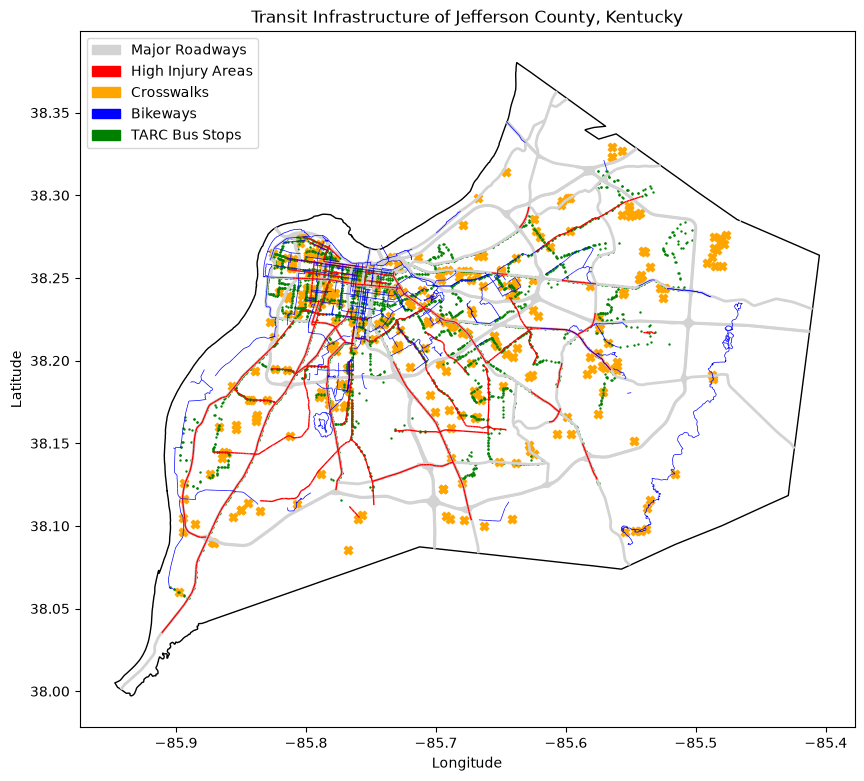

In [3]:
fig, ax = plt.subplots(figsize = (10, 10))

jefferson_co.plot(ax = ax, color='none', edgecolor='black')
jeffco_roads.plot(ax = ax, color='lightgray', linewidth=2) 
hi_injury.plot(ax = ax, color='red', linewidth=1)
crosswalks.plot(ax = ax, color='orange', marker="X")
bikeways.plot(ax = ax, color='blue', linewidth=0.5)
bus_stops.plot(ax = ax, color='green', markersize=0.5)

grey_lines = mpatches.Patch(color='lightgrey', label='Major Roadways')
red_lines = mpatches.Patch(color='red', label='High Injury Areas')
orange_xs = mpatches.Patch(color='orange', label='Crosswalks')
blue_lines = mpatches.Patch(color='blue', label='Bikeways')
green_dots = mpatches.Patch(color='green', label='TARC Bus Stops')

ax.legend(loc='upper left', handles=[grey_lines, red_lines, orange_xs, blue_lines, green_dots])

plt.title("Transit Infrastructure of Jefferson County, Kentucky")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

### Data Organization and Tidying

Collect dataframes in a list for batch processing of multiple dataframes.

In [4]:
data_sets = [bikeways, bus_stops, crosswalks, hi_injury]

Create a function to check dataframes for null values and fill those null value cells with values of the appropriate datatype.

In [5]:
def check_nulls(df):
    df_na = df.columns[df.isna().any()].tolist()
    if not df_na:
        pass   # if there are no missing values, do nothing.
    else:
        for i in df_na:
            if df[i].dtypes == 'str':
                df[i].fillna("None")   # if the missing value is in a string column, replace NaN with string "None"
            elif df[i].dtypes == 'float64':
                df[i].fillna(0)   # if the missing value is in a float column, replace the NaN with 0
            elif df[i].dtypes == 'int32':
                df[i].fillna(0)   # if the missing value is in an int column, replace the NaN with 0
            else:
                pass   # we happen to know that there are not other data types in these dataframes that will need to be filled, but further elif statements could be added here for additional datatypes if needed.

Apply null-checking function to all DataFrames being assessed.

In [6]:
for each_set in data_sets:
    check_nulls(each_set)

In the *bikeways* DataFrame, values of 1 - 5 are used to identify bikeways by type. The dictionary *bikeway_type* built below maps human-readable descriptions to each value 1 - 5 per the original dataset from https://data.louisvilleky.gov/datasets/LOJIC::jefferson-county-ky-bikeways

In [7]:
# 1 = Separated Bike Lane
# 2 = Bike Lane
# 3 = Neighborway
# 4 = Shared Lane Connection
# 5 = Shared Use Path

bikeway_type = {
    '1': 'Separated Bike Lane',
    '2': 'Bike Lane',
    '3': 'Neighborway',
    '4': 'Shared Lane Connection',
    '5': 'Shared Use Path'
}

Add a column to *bikeways* that indicates the type of bikeway by name rather than by number.

In [8]:
bikeways['TYPE_NAME'] = bikeways['MAP_TYPE'].map(bikeway_type)

In [9]:
bikeways_mls = bikeways.loc[bikeways['geometry'].geom_type == 'MultiLineString']
display(bikeways_mls)
bikeways_mt5 = bikeways.loc[bikeways['MAP_TYPE'] == '5']
display(bikeways_mt5)

,OBJECTID,ROADNAME,MAP_TYPE,MPWBIKEID,SHAPELEN,geometry,TYPE_NAME
1051,1052,VETERANS PARK,5,1112,707.905552,"MULTILINESTRING ((-85.55515 38.19127, -85.5551...",Shared Use Path
1054,1055,SKYVIEW PARK,5,1115,3524.768222,"MULTILINESTRING ((-85.56088 38.20208, -85.5609...",Shared Use Path


,OBJECTID,ROADNAME,MAP_TYPE,MPWBIKEID,SHAPELEN,geometry,TYPE_NAME
436,437,LETTERLE RD,5,442,575.636778,"LINESTRING (-85.71889 38.26105, -85.71882 38.2...",Shared Use Path
640,641,LANNAN PARK,5,655,2250.534448,"LINESTRING (-85.78704 38.27561, -85.78704 38.2...",Shared Use Path
641,642,LANNAN PARK,5,656,245.274042,"LINESTRING (-85.78384 38.27278, -85.78392 38.2...",Shared Use Path
642,643,LANNAN PARK,5,657,801.829949,"LINESTRING (-85.78388 38.27245, -85.78399 38.2...",Shared Use Path
643,644,BIG FOUR BRIDGE,5,658,4517.043646,"LINESTRING (-85.73564 38.26216, -85.73582 38.2...",Shared Use Path
...,...,...,...,...,...,...,...
1662,1663,BARRET AVE,5,1759,842.570037,"LINESTRING (-85.72692 38.2348, -85.72684 38.23...",Shared Use Path
1663,1664,BARRET AVE,5,1760,174.131852,"LINESTRING (-85.72448 38.23164, -85.72434 38.2...",Shared Use Path
1664,1665,MET,5,1761,3207.792901,"LINESTRING (-85.50948 38.24276, -85.50942 38.2...",Shared Use Path
1676,1677,MET,5,1773,3786.824098,"LINESTRING (-85.50948 38.24276, -85.50984 38.2...",Shared Use Path


A key part of this analysis intends to determine how much of Louisville's pedestrian (and cyclist) infrastructure falls within the "[high injury network](https://data.louisvilleky.gov/datasets/LOJIC::louisville-metro-ky-high-injury-network)." Because the GeoJSON files from Louisville Metro Open Data provide geographic shapes like linestrings, we will need to calculate linestring distances in miles. First, however, it must be determined whether amy dataset(s) contains multiple geometry shape types.

In [10]:
def check_shapes(df):
    if df['geometry'].geom_type.nunique() == 1:   # check whether only one geometry type exists in the dataframe, e.g. one consistent type for all values in 'geometry'
        pass
    else:
        print(f"Dataframe '{df.name}' contains {df.geom_type.nunique()} shape types.")

for each_set in data_sets:
    check_shapes(each_set)

Dataframe 'bikeways' contains 2 shape types.


*bikeways* contains two pesky rows where the geometry of the shape is MultiLineString.
Rather than defining a sub-function to handle just two anomolous values, GeoPandas can "explode" these. While sounding dramatic, exploding simply breaks the multiple linestrings each into their own new row. 

In [11]:
bikeways_original = bikeways   # back up the original bikeways DataFrame
bikeways = bikeways.explode(ignore_index=True)   # kaboom!

hi_injury_original = hi_injury
hi_injury = hi_injury.explode(ignore_index=True)

In [12]:
bikeways.to_csv('data/bikeways.csv')
hi_injury.to_csv('data/hi_injury.csv')

Geodata files by default provide length as measured in degrees. For a human-readable measure of distance, we must define a function that will calculate the cumulative length of the each segment's "linestring." Linestring is just a list of coordinates stored in an array, readable by *pandas*, *python*, and other software, that can be used to draw the segments accurately on map plots. 

(This step is why the *bikeways* set was exploded above.)

In [13]:
seg_length_mi = 0   # variable to store individual segment lengths
total_line_length = []   # list variable to capture the cumulative segment lengths from the function
def calc_length(line_geometry):
    
    print("\n *** FUNCTION BEGINS ***")
    
    global seg_length_mi    
    global total_line_length
    seg_length_mi = 0   # establish baseline segment length (e.g. no length at start)
    total_line_length = [] # clear total_line_length for re-use in each iteration of the upcoming for loop
    coords = list(line_geometry.coords)

    print("seg_length_mi: ",seg_length_mi)
    print("total_line_length: ",total_line_length)
    print("coords: ", coords)

    for p in range(len(coords) - 1):

        print("p: ",p)

        point1 = (coords[p][1], coords[p][0]) # geopy requires (latitude, longitude)
        point2 = (coords[p+1][1], coords[p+1][0])

        print("point1: ", point1)
        print("point2: ", point2)


        seg_length_mi += geodesic(point1, point2).mi   # add length between points in linestring to total segment length in miles

        print("seg_Length_mi: ", seg_length_mi)

    total_line_length.append(seg_length_mi)

    print("total_line_length: ",total_line_length)


# test area

In [14]:
# for ls in bikeways['geometry']:
#     calc_length(ls)

# for ls in hi_injury['geometry']:
#     calc_length(ls)

# end test area

Now, calculate the distances for each linestring segment, but only in DataFrames whose *geometry* type is *LineString*.

In [15]:
for each_set in data_sets:

    print("data_set: ", each_set.name)

    if each_set.at[0,'geometry'].geom_type != 'LineString':
        continue
    else:
        for ls in each_set['geometry']:

            selected_row = each_set[each_set['geometry'] == ls]
            print("row: ", selected_row)

            calc_length(ls)
        if not len (total_line_length) == len(each_set):
            print(f"Houston, we have a problem. The length of the list of distances differs from the length of the DataFrame '{each_set.name}'.")
            break
        else:
            each_set['LEN_MI'] = total_line_length

data_set:  bikeways
row:     OBJECTID     ROADNAME MAP_TYPE  MPWBIKEID    SHAPELEN  \
0         1  DUMESNIL ST        4          1  186.297444   

                                            geometry               TYPE_NAME  
0  LINESTRING (-85.79968 38.2367, -85.79914 38.23...  Shared Lane Connection  

 *** FUNCTION BEGINS ***
seg_length_mi:  0
total_line_length:  []
coords:  [(-85.7996835552989, 38.23670249644875), (-85.79913584598756, 38.23665423531368), (-85.7990390266429, 38.23664522079945)]
p:  0
point1:  (38.23670249644875, -85.7996835552989)
point2:  (38.23665423531368, -85.79913584598756)
seg_Length_mi:  0.02998112549892624
p:  1
point1:  (38.23665423531368, -85.79913584598756)
point2:  (38.23664522079945, -85.7990390266429)
seg_Length_mi:  0.03528473793711408
total_line_length:  [0.03528473793711408]
row:     OBJECTID     ROADNAME MAP_TYPE  MPWBIKEID   SHAPELEN  \
1         2  DUMESNIL ST        4          2  388.16377   

                                            geometry

NotImplementedError: Sub-geometries may have coordinate sequences, but multi-part geometries do not

In [ ]:
for item in bikeways['geometry']:
    calc_length(item)

print("bikeways len: ", len(bikeways))
print("total_line_length len: ",len(total_line_length))
hi_injury.at[0,'geometry'].geom_type

# *line_length* is returning one miles/distance value per segment, but it needs to return the sum of segment lengths per DataFrame row. 

late something something having to do with where the *line_length.append* is nested?

# Two dataframes have *linestring* geometries. Two have *point* geometries. 
Write a function to determine which dataframes have which geom_type, and write the df.name to identifying lists. 
Or... this overcomplicates in a stretch to meet the rubric: 3rd function. Maybe instead a function to write select columns to the SQL db file?

# **NOTE TO SELF:** The above function is built but not yet tested as of 6-Aug-2026. 
- You still need to apply this function to the geometry / linestring columns of your dataframes. 
- Generate a new column in each dataframe called (something like) "Segment Length (miles)"